In [2]:
import os

# change directory one up 
os.chdir('..')


In [3]:
import importlib
import utils
importlib.reload(utils)
from notebooks.utils import *

In [8]:
perf_df

,nll,loss,relevance_shift,param_idx
0,0.268034,0.268034,-3.0,0
0,0.243290,0.243290,-1.5,0
0,0.232464,0.232464,0.0,0
0,0.243799,0.243799,1.5,0
0,0.271556,0.271556,3.0,0
0,0.261258,0.261258,-3.0,1
0,0.241690,0.241690,-1.5,1
0,0.232464,0.232464,0.0,1
0,0.242386,0.242386,1.5,1
0,0.272865,0.272865,3.0,1


['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-1.5_idx11.csv', 'test_clicks_param_shift_-3.0_idx17.csv', 'test_clicks_param_shift_-3.0_idx16.csv', 'test_clicks_param_shift_-1.5_idx10.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.5_idx12.csv', 'test_clicks_param_shift_-3.0_idx14.csv', 'test_clicks_param_shift_-3.0_idx15.csv', 'test_clicks_param_shift_-1.5_idx13.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-1.5_idx17.csv', 'test_clicks_param_shift_-3.0_idx11.csv', 'test_clicks_param_shift_-3.0_idx10.csv', 'test_clicks_param_shift_-1.5_idx16.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_0.0_idx18.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-1.5_idx14.csv', 'test_clicks_param_shift_-3.0_idx12.csv', 'test_clicks_param_shift_-1.5_idx9.csv', 'test_cli

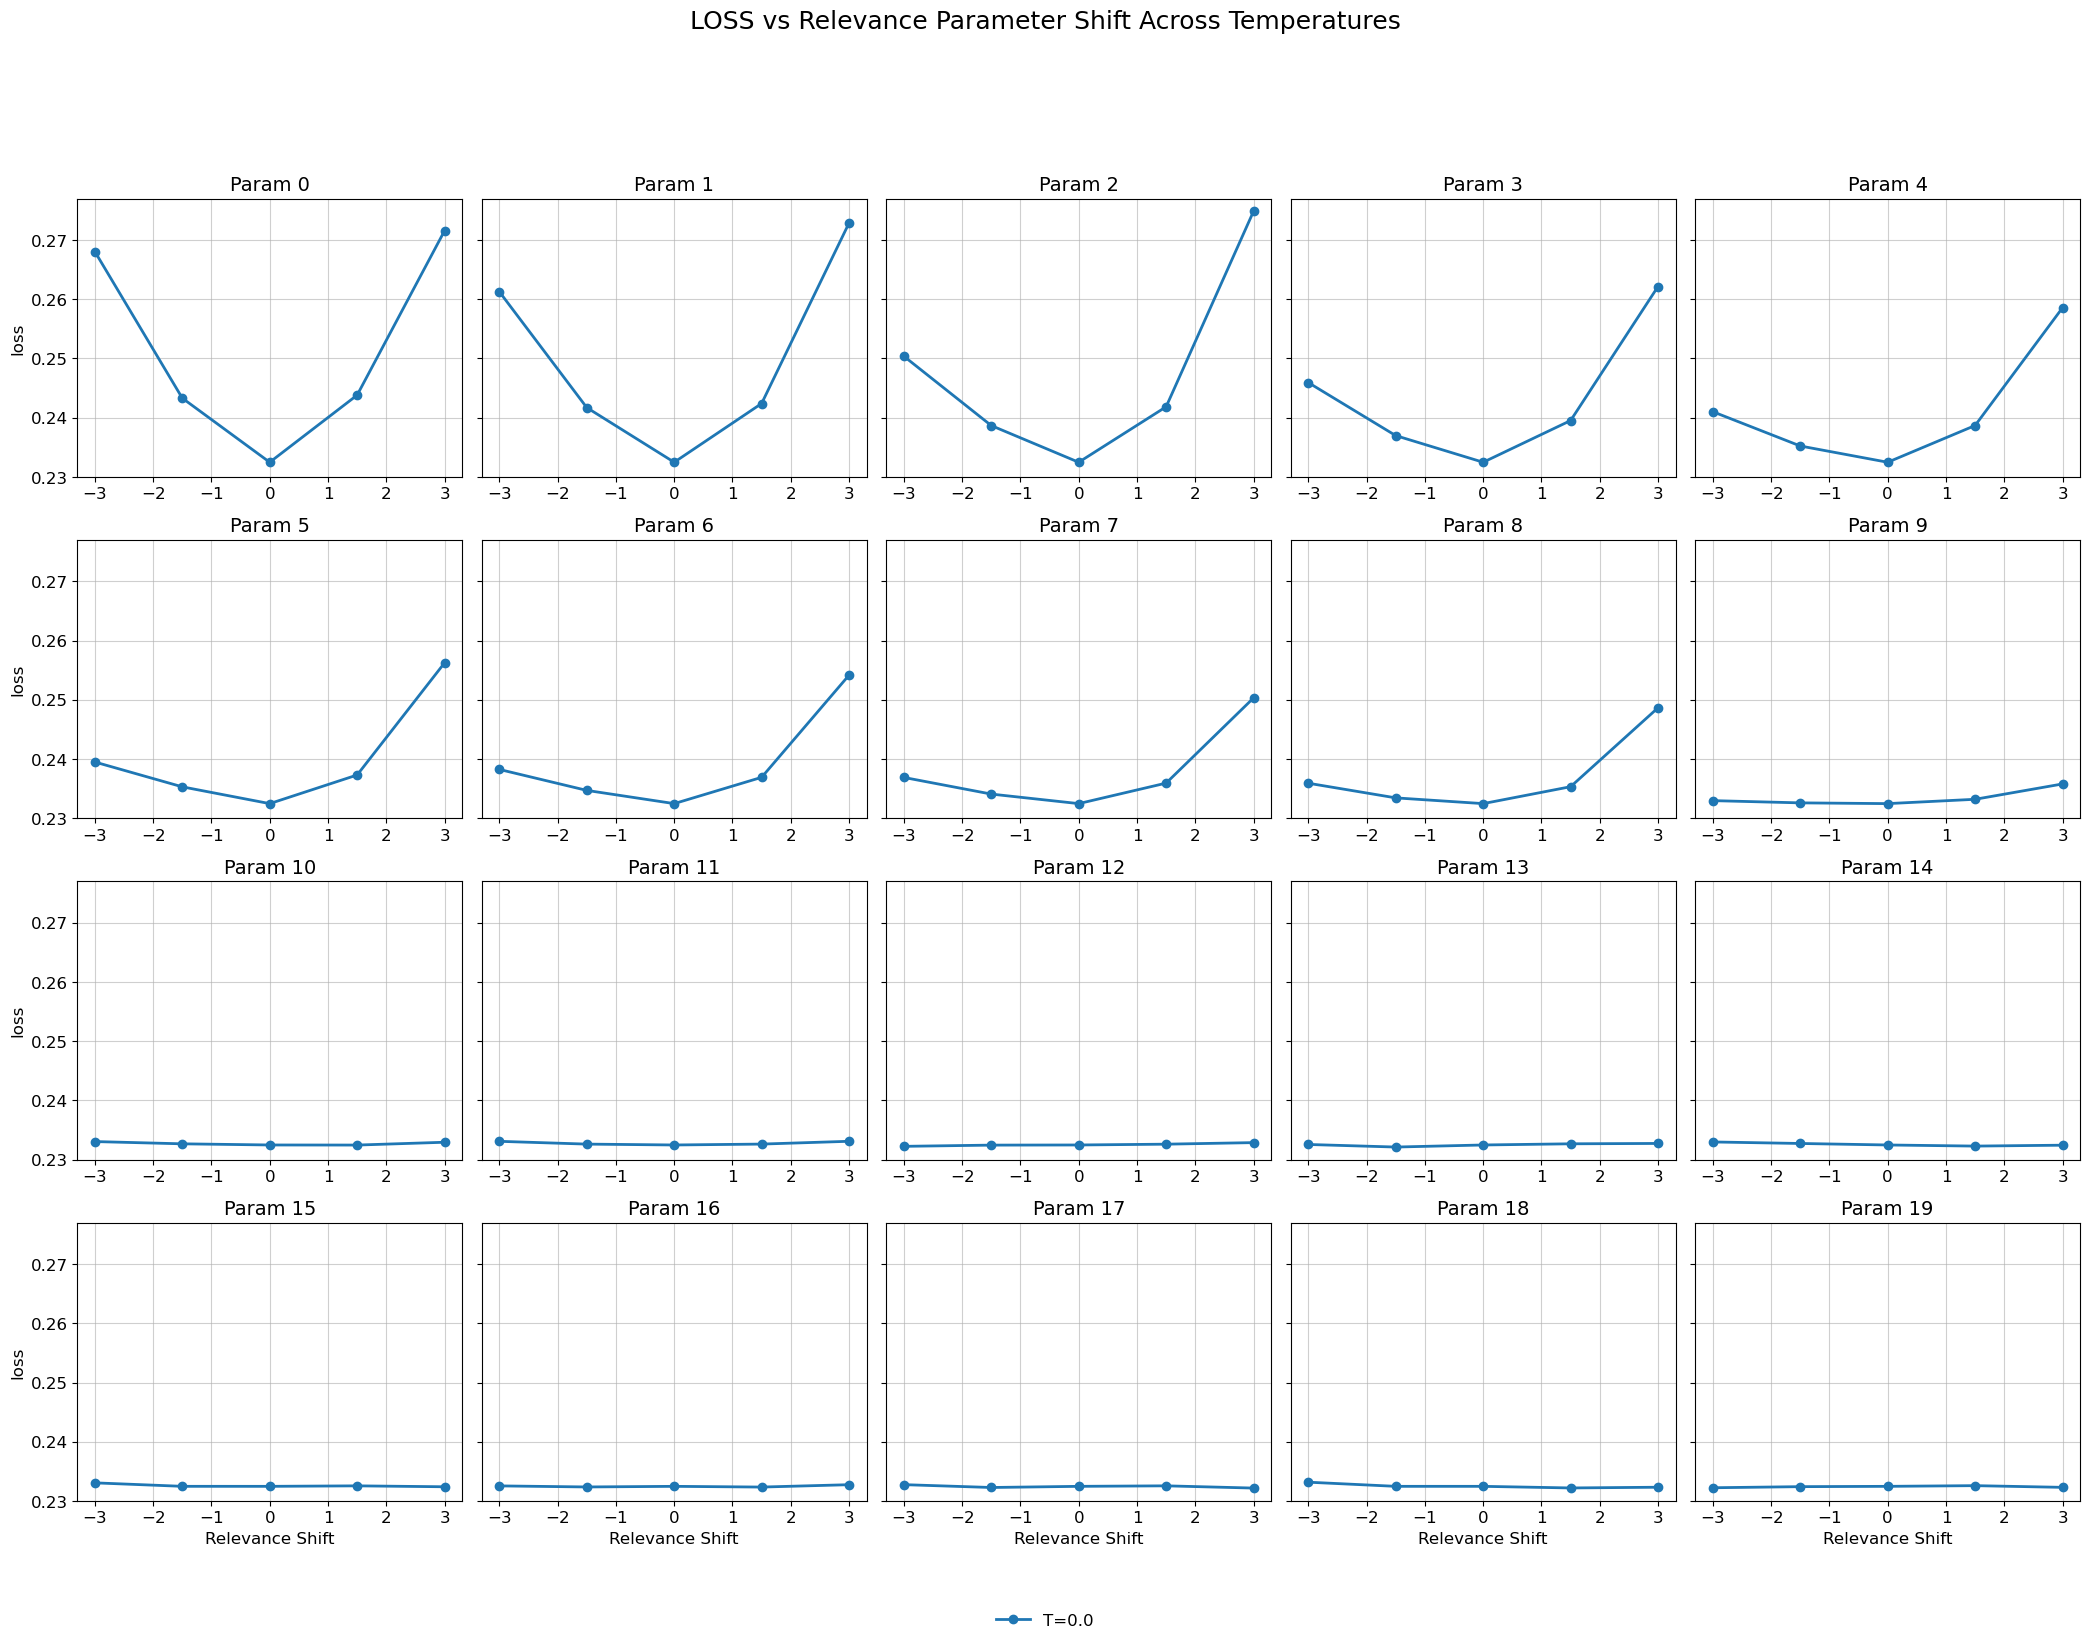

In [71]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'





folder_path = "results/test_baidu/data=Custom_dataset_deep,experiment=test_baidu,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"


# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx'
)

# Load relevance
rel_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_relevance,
    'relevance_shift',
    'param_idx'
)


# ✅ Now you can plot, just reversing the meaning of the axes
# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, doc_group_sizes, temperatures)
plot_performance_grid_all_temps([perf_df], [0.0], metric='loss')

In [72]:
data = np.load("../ltr_datasets/train_Baidu_ULTRA_part1.npz", allow_pickle=True)
padded_positions = data['padded_positions']
counts = np.sum(padded_positions != -1, axis=0)
perf_df["sample_count"] = perf_df["param_idx"].map(
    {i: count for i, count in enumerate(counts)}
)

In [74]:
print(counts)

[500218 486031 515128 514036 519158 524814 549096 521379 556559  68571
  24396  22515  16248  11565   7040   3907   2119   1345    619     27]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_performance_by_param(
    df,
    metric='loss',
    diff_from_zero=False,
    with_comparison=True,
    max_cols=5
):
    required_cols = {'relevance_shift', 'param_idx', metric, 'sample_count'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

    param_values = sorted(df['param_idx'].unique())
    n_params = len(param_values)

    # --- Compute grid size ---
    n_cols = min(max_cols, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3.2 * n_rows),
        sharey=True
    )

    # Ensure axes is always 2D array
    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    first_ax = [axes[i][0] for i in range(n_rows)]
    all_y_values = []

    # Colors
    tab10 = plt.get_cmap('tab10').colors
    desired_colors = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']
    color_sequence = desired_colors + [c for c in tab10 if c not in desired_colors]
    color_map = {param: color_sequence[i % len(color_sequence)] for i, param in enumerate(param_values)}

    # Comparison lines
    COMPARISON_LINES = [
        (2.71, 'p=0.10'),
        (3.84, 'p=0.05'),
        (6.63, 'p=0.01'),
        (10.83, 'p=0.001')
    ]

    # --- Loop over grid ---
    for idx, param in enumerate(param_values):
        r = idx // n_cols
        c = idx % n_cols
        ax = axes[r][c]

        sub_p = df[df["param_idx"] == param].sort_values("relevance_shift")
        if sub_p.empty:
            ax.axis("off")
            continue

        # Compute y-values
        if diff_from_zero:
            baseline_vals = sub_p.loc[sub_p["relevance_shift"] == 0, metric]
            if baseline_vals.empty:
                baseline = sub_p.iloc[(sub_p["relevance_shift"] - 0).abs().idxmin()][metric]
            else:
                baseline = baseline_vals.mean()

            # Multiply per row by sample_count
            y_values = (sub_p[metric] - baseline) * sub_p['sample_count']
            label = f"Param {param} (Δ × samples)"
        else:
            y_values = sub_p[metric]
            label = f"Param {param}"

        color = color_map[param]

        ax.plot(
            sub_p["relevance_shift"],
            y_values,
            marker="o", lw=2,
            color=color,
            label=label
        )

        all_y_values.extend(np.asarray(y_values).tolist())
        ax.set_title(f"Param {param}", fontsize=10)
        ax.set_xlabel("Bias Shift ($s$)")

        # Only first subplot shows y-axis labels
        if ax in first_ax:
            y_label = metric if not diff_from_zero else f"Δ {metric} × samples"
            ax.set_ylabel(y_label)
        else:
            ax.tick_params(labelleft=False)

        # --- Comparison lines ---
        if with_comparison:
            xmin, xmax = ax.get_xlim()
            for yval, txt in COMPARISON_LINES:
                ax.axhline(y=yval, color="black", linestyle="--", lw=1.1)
                ax.text(
                    xmax * 0.98, yval + 0.05,
                    txt,
                    fontsize=8, ha="right", va="bottom",
                    backgroundcolor="white"
                )

        # Legend
        ax.legend(frameon=False, fontsize=8, loc="upper left")

    # Turn off unused axes
    total_cells = n_rows * n_cols
    for empty_idx in range(n_params, total_cells):
        r = empty_idx // n_cols
        c = empty_idx % n_cols
        axes[r][c].axis("off")

    # --- Shared y-limits ---
    if all_y_values:
        margin = max(np.std(all_y_values) * 1.1, 0.1)
        ymin, ymax = min(all_y_values) - margin, max(all_y_values) + margin
        ymax = 16
        ymin = max(ymin, -1.5)
        for ax in first_ax:
            ax.set_ylim(ymin, ymax)

    # Fix whitespace
    fig.subplots_adjust(
        top=0.92,
        bottom=0.12,
        left=0.07,
        right=0.98,
        wspace=0.15,
        hspace=0.35
    )

    plt.show()


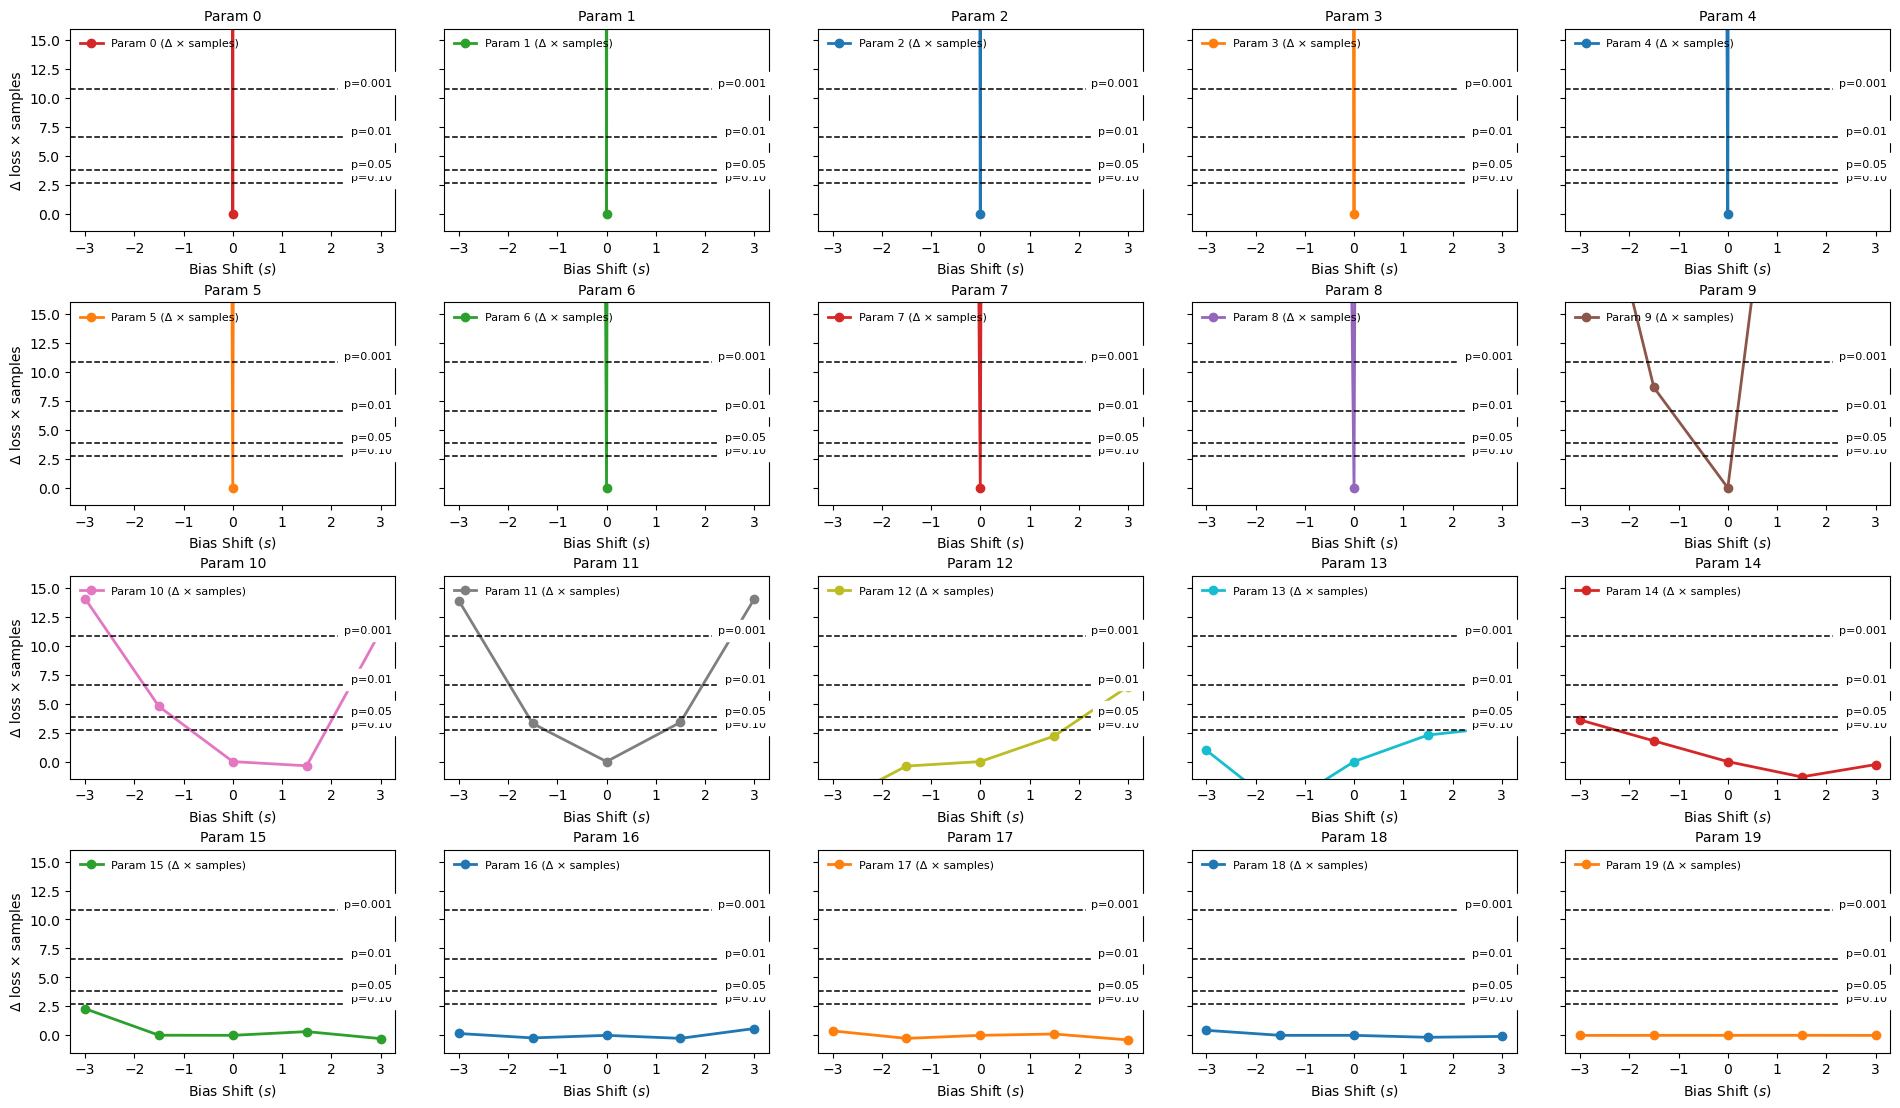

In [76]:
plot_performance_by_param(perf_df, metric="loss", diff_from_zero=True, with_comparison=True)


In [77]:
perf_df

,nll,loss,relevance_shift,param_idx,sample_count
0,0.268034,0.268034,-3.0,0,500218
0,0.243290,0.243290,-1.5,0,500218
0,0.232464,0.232464,0.0,0,500218
0,0.243799,0.243799,1.5,0,500218
0,0.271556,0.271556,3.0,0,500218
...,...,...,...,...,...
0,0.232226,0.232226,-3.0,19,27
0,0.232410,0.232410,-1.5,19,27
0,0.232464,0.232464,0.0,19,27
0,0.232580,0.232580,1.5,19,27


In [154]:
from scipy.stats import chi2

# Compute global delta loss first
baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]

def compute_identifiability(df, thresholds=[0.05, 0.001, 0.0001]):
    required_cols = {'relevance_shift', 'param_idx', 'loss', 'sample_count', 'delta_loss', 'delta_loss_times_samples'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

    identifiability_results = {}
    param_values = sorted(df['param_idx'].unique())

    print(f"Evaluated {len(param_values)} parameter values for identifiability")
    print(f"Shifted across {df['relevance_shift'].nunique()} relevance shifts, "
          f"ranging from {df['relevance_shift'].min()} to {df['relevance_shift'].max()}\n")

    chi2_critical = {thr: chi2.ppf(1 - thr, df=1) for thr in thresholds}

    # Print header
    print(f"{'Param':>5} | {'p-val':>8} | {'Neg Shift':>10} | {'Pos Shift':>10} | {'Avg ΔLoss':>10} | {'Samples':>10} | {'Conclusion':>20}")
    print("-" * 100)

    for param in param_values:
        sub_p = df[df["param_idx"] == param].sort_values("relevance_shift")
        if sub_p.empty:
            continue

        # Determine strongest threshold per shift
        neg_threshold = None
        pos_threshold = None
        min_negative_shift = None
        min_positive_shift = None

        for thr in sorted(chi2_critical.keys()):
            crit_value = chi2_critical[thr]
            if neg_threshold is None:
                negative_shifts = sub_p.loc[(sub_p["relevance_shift"] < 0) &
                                            (sub_p["delta_loss_times_samples"] >= crit_value)]
                if not negative_shifts.empty:
                    neg_threshold = thr
                    min_negative_shift = max(negative_shifts["relevance_shift"])
            if pos_threshold is None:
                positive_shifts = sub_p.loc[(sub_p["relevance_shift"] > 0) &
                                            (sub_p["delta_loss_times_samples"] >= crit_value)]
                if not positive_shifts.empty:
                    pos_threshold = thr
                    min_positive_shift = min(positive_shifts["relevance_shift"])
            if neg_threshold is not None and pos_threshold is not None:
                break

        # Average delta loss per parameter (weighted)
        avg_delta_loss = sub_p["delta_loss_times_samples"].sum() / sub_p["sample_count"].sum()
        total_samples = sub_p["sample_count"].sum()

        # Draw conclusion
        if neg_threshold is None and pos_threshold is None:
            conclusion = "likely unidentified"
        elif (neg_threshold in [0.0001, 0.001] and pos_threshold in [0.0001, 0.001]):
            conclusion = "likely identified"
        elif (neg_threshold is not None and pos_threshold is not None and 
              neg_threshold <= 0.05 and pos_threshold <= 0.05):
            conclusion = "weakly identified"
        elif (neg_threshold is None or pos_threshold is None):
            conclusion = "likely practically unidentified"
        else:
            conclusion = "unidentified"

        identifiability_results[param] = ((neg_threshold, pos_threshold),
                                         (min_negative_shift, min_positive_shift),
                                         avg_delta_loss,
                                         total_samples,
                                         conclusion)

        # Print aligned
        neg_shift_str = f"{min_negative_shift:.1f}" if min_negative_shift is not None else "None"
        pos_shift_str = f"{min_positive_shift:.1f}" if min_positive_shift is not None else "None"
        neg_thr_str = f"{neg_threshold}" if neg_threshold is not None else "None"

        print(f"{param:>5} | {neg_thr_str:>8} | {neg_shift_str:>10} | {pos_shift_str:>10} | "
              f"{avg_delta_loss:>10.6f} | {total_samples:>10} | {conclusion:>20}")

    return identifiability_results

# Usage
identifiability_results = compute_identifiability(perf_df, thresholds=[0.05, 0.001, 0.0001])


Evaluated 20 parameter values for identifiability
Shifted across 5 relevance shifts, ranging from -3.0 to 3.0

Param |    p-val |  Neg Shift |  Pos Shift |  Avg ΔLoss |    Samples |           Conclusion
----------------------------------------------------------------------------------------------------
    0 |   0.0001 |       -1.5 |        1.5 |   0.019365 |    2501090 |    likely identified
    1 |   0.0001 |       -1.5 |        1.5 |   0.017669 |    2430155 |    likely identified
    2 |   0.0001 |       -1.5 |        1.5 |   0.015169 |    2575640 |    likely identified
    3 |   0.0001 |       -1.5 |        1.5 |   0.010933 |    2570180 |    likely identified
    4 |   0.0001 |       -1.5 |        1.5 |   0.008716 |    2595790 |    likely identified
    5 |   0.0001 |       -1.5 |        1.5 |   0.007692 |    2624070 |    likely identified
    6 |   0.0001 |       -1.5 |        1.5 |   0.006827 |    2745480 |    likely identified
    7 |   0.0001 |       -1.5 |        1.5 |   0.005

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_46961/526035591.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap("tab10")


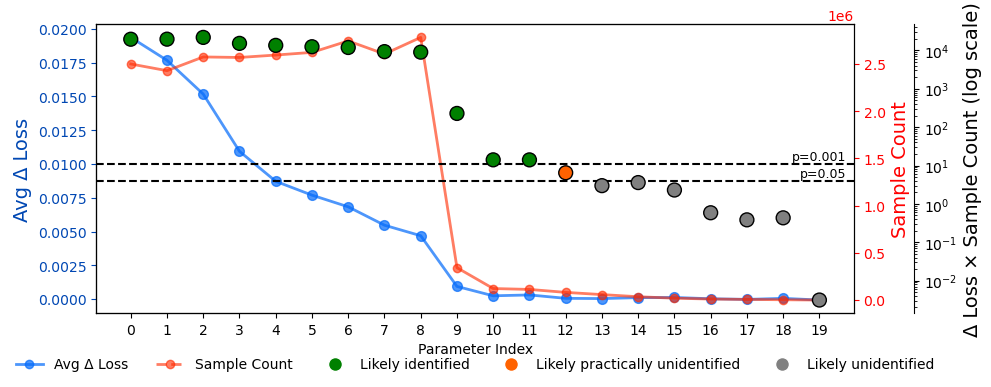

In [252]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from matplotlib import cm

tab10 = cm.get_cmap("tab10")

# Extract data per parameter
params = sorted(identifiability_results.keys())
avg_delta_loss = [identifiability_results[p][2] for p in params]
sample_counts = [identifiability_results[p][3] for p in params]
conclusions = [identifiability_results[p][4].strip().lower() for p in params]

# Δ Loss × Sample Count
delta_loss_times_samples = (
    perf_df.groupby("param_idx")["delta_loss"].max()
    * perf_df.groupby("param_idx")["sample_count"].mean()
)
delta_loss_times_samples = [delta_loss_times_samples.get(p, 0) for p in params]

# Brighter color choices for labels & lines
avg_loss_color = "#046BFAB5"     # bright blue
sample_count_color = "#FF2A009C" # bright red
avg_loss_text_color = "#0047B3" # darker blue
sample_count_text_color = "#FF0000" # darker red

color_map = {
    "likely identified": "green",
    "likely practically unidentified": "#FF6200",
    "likely unidentified": "gray"
}
dot_colors = [color_map[c] for c in conclusions]

# Threshold lines
COMPARISON_LINES = [
    (3.84, 'p=0.05'),
    (10.83, 'p=0.001'),
]

# ---- FIGURE ----
fig, ax1 = plt.subplots(figsize=(10, 4))

# Avg Δ Loss
ax1.plot(
    params, avg_delta_loss,
    color=avg_loss_color,
    marker='o', markersize=7, linewidth=2
)
ax1.set_xlabel("Parameter Index")
ax1.set_xticks(params)

ax1.set_ylabel("Avg Δ Loss", color=avg_loss_text_color, fontsize=14)
ax1.tick_params(axis="y", colors=avg_loss_text_color)
ax1.spines["left"].set_color("black")
ax1.grid(False)

# Sample Count line + dots
ax2 = ax1.twinx()
ax2.plot(
    params, sample_counts,
    color=sample_count_color,
    linestyle='-', linewidth=2,
    marker='o', markersize=6
)
ax2.set_ylabel("Sample Count", color=sample_count_text_color, fontsize=14)
ax2.tick_params(axis="y", colors=sample_count_text_color)
ax2.spines["right"].set_color("black")


    
# Δ Loss × Sample Count scatter
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.08))
ax3.scatter(params, delta_loss_times_samples, color=dot_colors, edgecolor='black', s=100)
ax3.set_ylabel("Δ Loss × Sample Count (log scale)", color="black", fontsize=14)
ax3.tick_params(axis="y", colors="black")
ax3.spines["right"].set_color("black")
ax3.set_yscale("log")
# Threshold lines
for yval, label in COMPARISON_LINES:
    ax3.axhline(y=yval, color="black", ls="--", lw=1.5, zorder=-10)
    ax3.text(
        ax3.get_xlim()[1] * 0.99, yval * 1.06,
        label, ha="right", va="bottom",
        fontsize=9, color="black"
    )


# Legend
legend_elements = [
    Line2D([0], [0], color=avg_loss_color, lw=2, marker='o',
           markersize=6, label="Avg Δ Loss"),
    Line2D([0], [0], color=sample_count_color, lw=2, linestyle="--",
           marker='o', markersize=6, label="Sample Count"),
] + [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=color, markersize=10, label=label.capitalize())
    for label, color in color_map.items()
]

ax1.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
    ncol=len(legend_elements),
    frameon=False
)

plt.tight_layout()
plt.show()

In [138]:
chi2.ppf(1 - 0.0001, 1)


np.float64(15.136705226623604)

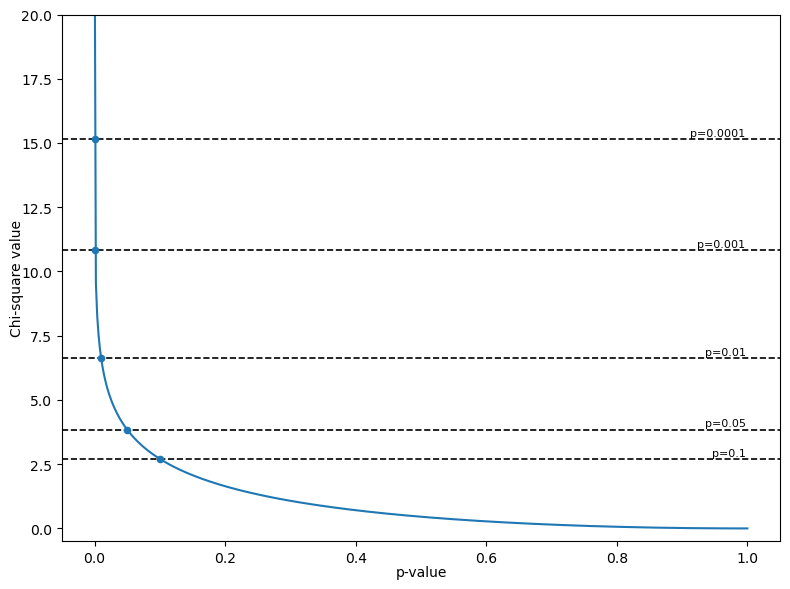

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# choose degrees of freedom
df = 1

# p-values from 0 to 1 (but avoid exactly 0)
p = np.linspace(0.000001, 0.9999, 500)
chi_vals = chi2.ppf(1 - p, df)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(p, chi_vals)

# special p-values
special_p = np.array([0.01, 0.05, 0.10, 0.001, 0.0001])
special_chi = chi2.ppf(1 - special_p, df)

# --- draw horizontal red dashed lines instead of dots ---
COMPARISON_LINES = list(zip(special_chi, [f"p={p}" for p in special_p]))

xmin, xmax = ax.get_xlim()

for yval, label in COMPARISON_LINES:
    ax.axhline(y=yval, color="black", ls="--", lw=1.2, alpha=1)
    ax.text(
        xmax * 0.95, yval + 0.05,
        label, color="black", fontsize=8, ha="right", va="bottom",
        backgroundcolor="white", alpha=1,
        zorder=-10
    )
special_p = np.array([0.01, 0.05, 0.10, 0.001, 0.0001])
special_chi = chi2.ppf(1 - special_p, df)

plt.scatter(special_p, special_chi, s=20, zorder=5)
ax.set_ylim(-0.5, 20)
# labels
ax.set_xlabel("p-value")
ax.xaxis.labelpad = 0
ax.set_ylabel("Chi-square value")
ax.yaxis.labelpad = -2
plt.tight_layout()
plt.savefig("notebooks/plots/chi_square_p_values.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()


In [228]:
print(delta_loss_times_samples_neg)
print(delta_loss_times_samples_pos)

[np.float64(17792.75926218002), np.float64(13994.723150590022), np.float64(9222.89807352002), np.float64(6912.6584611600165), np.float64(4431.252342680012), np.float64(3685.3803596400157), np.float64(3168.5529770400094), np.float64(2304.8392901400107), np.float64(1915.4701511700162), np.float64(34.55498403000093), np.float64(14.065757760000768), np.float64(13.891980150000652), np.float64(-0.3858899999998222), np.float64(0.9799024500003797), np.float64(3.5941312000000636), np.float64(2.299933690000052), np.float64(0.1590097600000555), np.float64(0.38398405000003644), np.float64(0.4333928500000065), np.float64(-0.00144584999999961)]
[np.float64(19554.742151920003), np.float64(19636.284240300014), np.float64(21830.676478640024), np.float64(15257.13335816002), np.float64(13543.819861900016), np.float64(12475.22763864), np.float64(11913.055032960005), np.float64(9301.797608040006), np.float64(9007.261806560018), np.float64(227.7524051100017), np.float64(11.252411040000718), np.float64(14.04

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_46961/2291221883.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap("tab10")


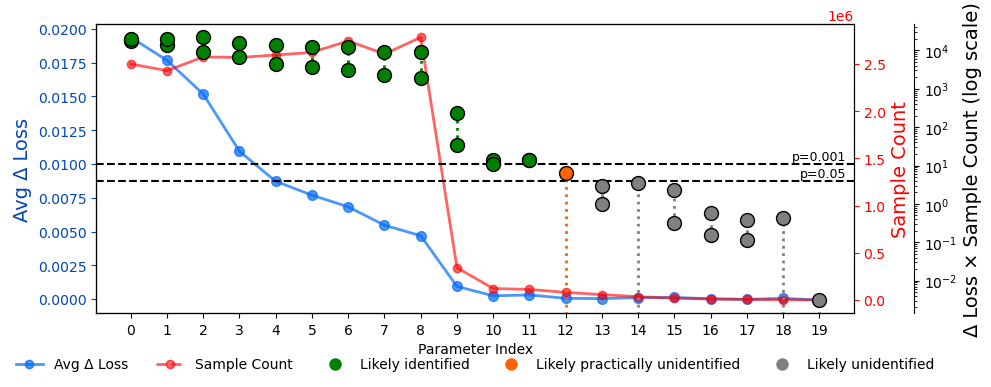

In [254]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from matplotlib import cm

tab10 = cm.get_cmap("tab10")

# Extract data per parameter
params = sorted(identifiability_results.keys())
avg_delta_loss = [identifiability_results[p][2] for p in params]
sample_counts = [identifiability_results[p][3] for p in params]
conclusions = [identifiability_results[p][4].strip().lower() for p in params]

# Δ Loss × Sample Count
delta_loss_times_samples_neg = (
    perf_df[perf_df["relevance_shift"] < 0].groupby("param_idx")["delta_loss"].max()
    * perf_df[perf_df["relevance_shift"] < 0].groupby("param_idx")["sample_count"].mean()
)
delta_loss_times_samples_neg = [delta_loss_times_samples_neg.get(p, 0) for p in params]

delta_loss_times_samples_pos = (
    perf_df[perf_df["relevance_shift"] > 0].groupby("param_idx")["delta_loss"].max()
    * perf_df[perf_df["relevance_shift"] > 0].groupby("param_idx")["sample_count"].mean()
)
delta_loss_times_samples_pos = [delta_loss_times_samples_pos.get(p, 0) for p in params]

# Brighter color choices for labels & lines
avg_loss_color = "#046BFAB5"     # bright blue
sample_count_color = "#FF00009C" # bright red
avg_loss_text_color = "#0047B3" # darker blue
sample_count_text_color = "#FF0000" # darker red

color_map = {
    "likely identified": "green",
    "likely practically unidentified": "#FF6200",
    "likely unidentified": "gray"
}
dot_colors = [color_map[c] for c in conclusions]

# Threshold lines
COMPARISON_LINES = [
    (3.84, 'p=0.05'),
    (10.83, 'p=0.001'),
]

# ---- FIGURE ----
fig, ax1 = plt.subplots(figsize=(10, 4))

# Avg Δ Loss
ax1.plot(
    params, avg_delta_loss,
    color=avg_loss_color,
    marker='o', markersize=7, linewidth=2
)
ax1.set_xlabel("Parameter Index")
ax1.set_xticks(params)

ax1.set_ylabel("Avg Δ Loss", color=avg_loss_text_color, fontsize=14)
ax1.tick_params(axis="y", colors=avg_loss_text_color)
ax1.spines["left"].set_color("black")

# Sample Count line + dots
ax2 = ax1.twinx()
ax2.plot(
    params, sample_counts,
    color=sample_count_color,
    linestyle='-', linewidth=2,
    marker='o', markersize=6
)
ax2.set_ylabel("Sample Count", color=sample_count_text_color, fontsize=14)
ax2.tick_params(axis="y", colors=sample_count_text_color)
ax2.spines["right"].set_color("black")


    
# Δ Loss × Sample Count scatter
# Δ Loss × Sample Count scatter with vertical dotted lines and outlined dots
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.08))

for i, p in enumerate(params):
    y_neg = delta_loss_times_samples_neg[i]
    y_pos = delta_loss_times_samples_pos[i]
    color = dot_colors[i]  # same as the dot color based on conclusion

    # Draw vertical dotted line connecting negative and positive shift points
    ax3.vlines(
        x=p,
        ymin=min(y_neg, y_pos),
        ymax=max(y_neg, y_pos),
        color=color,
        linewidth=2,
        linestyle=':'
    )

    # Draw the dots on top with black edge
    ax3.scatter(p, y_neg, color=color, edgecolor='black', s=100, zorder=2, linewidth=1)
    ax3.scatter(p, y_pos, color=color, edgecolor='black', s=100, zorder=2, linewidth=1)

ax3.set_ylabel("Δ Loss × Sample Count (log scale)", color="black", fontsize=14)
ax3.tick_params(axis="y", colors="black")
ax3.spines["right"].set_color("black")
ax3.set_yscale("log")


# Threshold lines
for yval, label in COMPARISON_LINES:
    ax3.axhline(y=yval, color="black", ls="--", lw=1.5, zorder=-10)
    ax3.text(
        ax3.get_xlim()[1] * 0.99, yval * 1.06,
        label, ha="right", va="bottom",
        fontsize=9, color="black"
    )

# Legend
legend_elements = [
    Line2D([0], [0], color=avg_loss_color, lw=2, marker='o',
           markersize=6, label="Avg Δ Loss"),
    Line2D([0], [0], color=sample_count_color, lw=2, linestyle="--",
           marker='o', markersize=6, label="Sample Count"),
] + [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=color, markersize=10, label=label.capitalize())
    for label, color in color_map.items()
]

ax1.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
    ncol=len(legend_elements),
    frameon=False
)

plt.tight_layout()
plt.show()